🔷 Introduction

This project aims to predict the delivery time of food orders using machine learning techniques. With the rapid growth of online food delivery services, accurately estimating delivery time has become essential for improving customer satisfaction and operational efficiency.

The model analyzes various factors such as delivery distance, traffic conditions, weather, order details, and delivery partner performance to estimate the time required for delivery.

🔷 Objective

To build a machine learning model that predicts food delivery time
To analyze the impact of different factors on delivery duration
To improve prediction accuracy using data preprocessing and feature selection

🔷 Dataset

The dataset used in this project is obtained from Kaggle. It contains over 40,000 records of food delivery data, including features such as distance, traffic density, weather conditions, and delivery time.

The dataset includes raw and unstructured data with missing values, making it suitable for practicing data cleaning and preprocessing techniques.

🔷 Problem Type

This is a Regression Problem, as the goal is to predict a continuous numerical value (delivery time).

🔷 Tools & Technologies

Python

Pandas

NumPy

Matplotlib

Seaborn

Scikit-learn


🔷 Expected Outcome

The model will predict delivery time based on input features, helping delivery platforms provide accurate time estimates and improve overall efficiency.

🔷 Data Understanding

In this step, the dataset is explored to understand its structure, features, and overall quality. Understanding the data is important before performing preprocessing and model building.

The dataset consists of multiple features related to food delivery, such as delivery distance, traffic conditions, weather, order details, and delivery partner information. The target variable in this project is delivery time, which needs to be predicted.

Key aspects analyzed in this step include:

• Number of rows and columns in the dataset

• Data types of each feature

• Presence of missing or null values

• Overview of feature distributions


This step helps in identifying important features and potential issues in the dataset, which will be handled during preprocessing.


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Food Delivery Time Prediction Case Study.csv to Food Delivery Time Prediction Case Study.csv


In [ ]:
import os
os.listdir()

['.config',
 'kaggle (1).json',
 'food delivery time prediction.zip',
 'kaggle.json',
 'Food Delivery Time Prediction Case Study.csv',
 'sample_data']

In [ ]:
import pandas as pd

df = pd.read_csv('Food Delivery Time Prediction Case Study.csv',
                 encoding='latin1',
                 engine='python',
                 on_bad_lines='skip')

df.head()

,ï»¿ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Type_of_order,Type_of_vehicle,Time_taken(min)
0,4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,Snack,motorcycle,24
1,B379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,Snack,scooter,33
2,5D6D,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,Drinks,motorcycle,26
3,7A6A,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,Buffet,motorcycle,21
4,70A2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,Snack,scooter,30


In [ ]:
df.rename(columns={'ï»¿ID': 'ID'}, inplace=True)

In [ ]:
df.drop(['ID', 'Delivery_person_ID'], axis=1, inplace=True)

In [ ]:
df = df.dropna()

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop('Time_taken(min)', axis=1)
y = df['Time_taken(min)']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error

mean_absolute_error(y_test, y_pred)

6.602852966274916

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

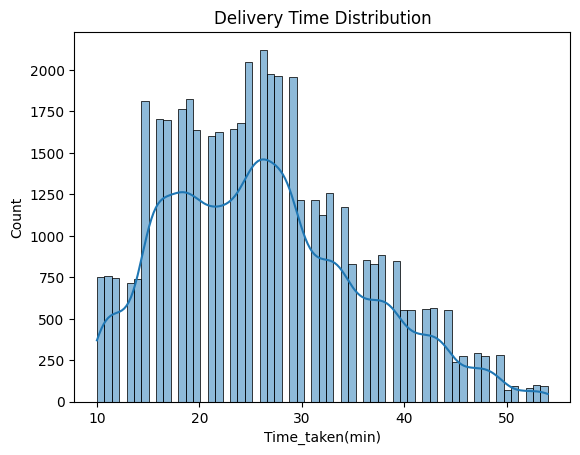

In [ ]:
sns.histplot(df['Time_taken(min)'], kde=True)
plt.title("Delivery Time Distribution")
plt.show()

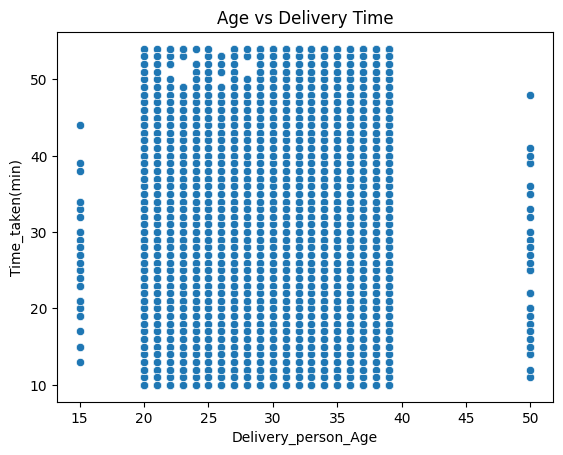

In [ ]:
sns.scatterplot(x='Delivery_person_Age', y='Time_taken(min)', data=df)
plt.title("Age vs Delivery Time")
plt.show()

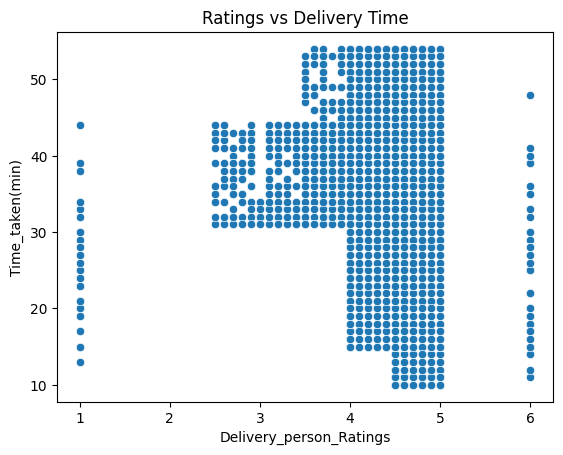

In [ ]:
sns.scatterplot(x='Delivery_person_Ratings', y='Time_taken(min)', data=df)
plt.title("Ratings vs Delivery Time")
plt.show()

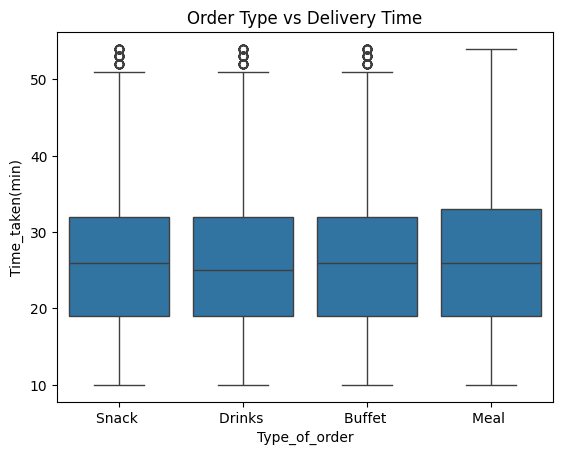

In [ ]:
sns.boxplot(x='Type_of_order', y='Time_taken(min)', data=df)
plt.title("Order Type vs Delivery Time")
plt.show()

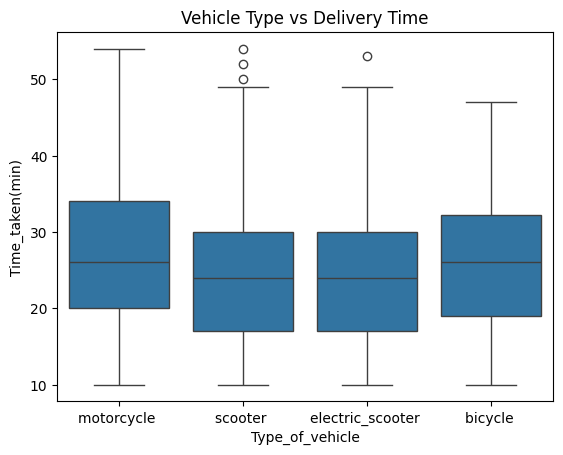

In [ ]:
sns.boxplot(x='Type_of_vehicle', y='Time_taken(min)', data=df)
plt.title("Vehicle Type vs Delivery Time")
plt.show()

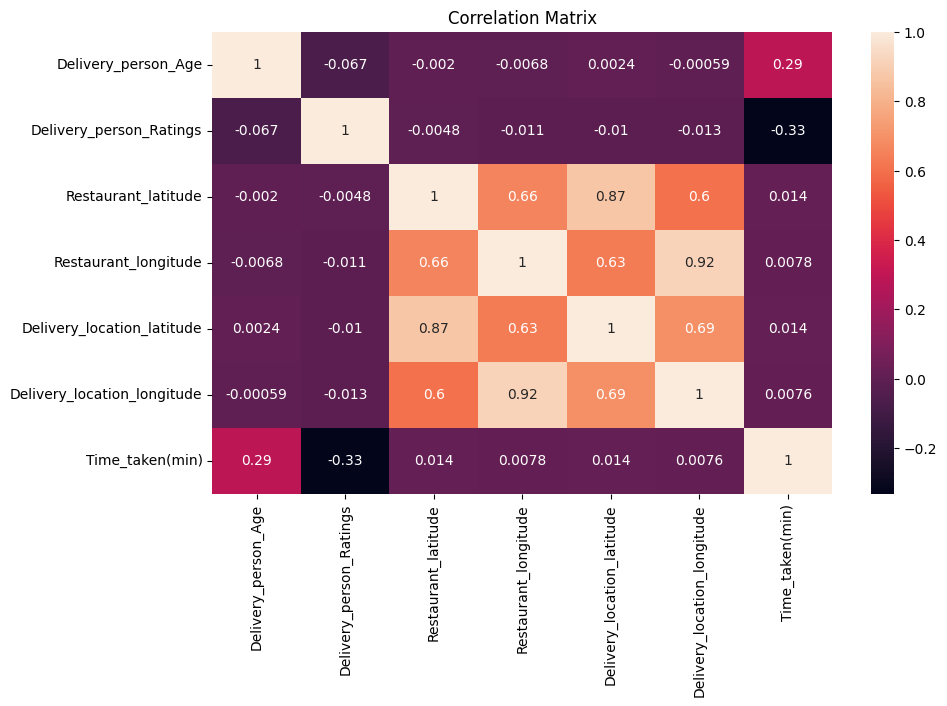

In [ ]:
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True)

plt.title("Correlation Matrix")
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

MAE: 6.602852966274916
MSE: 69.211272748953


📊 PROJECT CONCLUSION

This project focused on predicting food delivery time using machine learning techniques. The dataset was analyzed and preprocessed to remove inconsistencies, handle missing values, and prepare it for modeling.

From the exploratory data analysis (EDA), several important insights were observed:

 1. The delivery time distribution shows that most orders are delivered within 20 to 35 minutes, with a few higher-time outliers.

2. There is no strong relationship between delivery partner age and delivery time, indicating age does not significantly impact performance.

3. Delivery partner ratings show a slight trend, where higher-rated partners tend to deliver slightly faster, but the effect is not very strong.

4. Different types of orders (Snack, Drinks, Buffet, Meal) have similar delivery times, meaning order type does not heavily influence delivery duration.

5. Some extreme values (outliers) exist, which may be due to traffic, distance, or unexpected delays.

After preprocessing, a Linear Regression model was applied since the problem is a regression task. The model was trained and evaluated using test data to predict delivery time.
